In [ ]:
# import sys
# print(sys.executable)

/Users/grigoriostsakalis/Desktop/UniAI/makeathon-2026-WHOAMI-inform/.venv/bin/python


**Library Installation**

In [16]:
!pip install pytesseract groq tqdm opencv-python-headless pillow -q
!apt-get install tesseract-ocr -q

zsh:1: command not found: apt-get


**Groq setup for LLM Access**

In [2]:
# Groq Subscription Key for OCR recognition
# from kaggle_secrets import UserSecretsClient
# user_secrets = UserSecretsClient()
# secret_value_0 = user_secrets.get_secret("GROQ_API_KEY ")

**High Level Architectural Diagram**

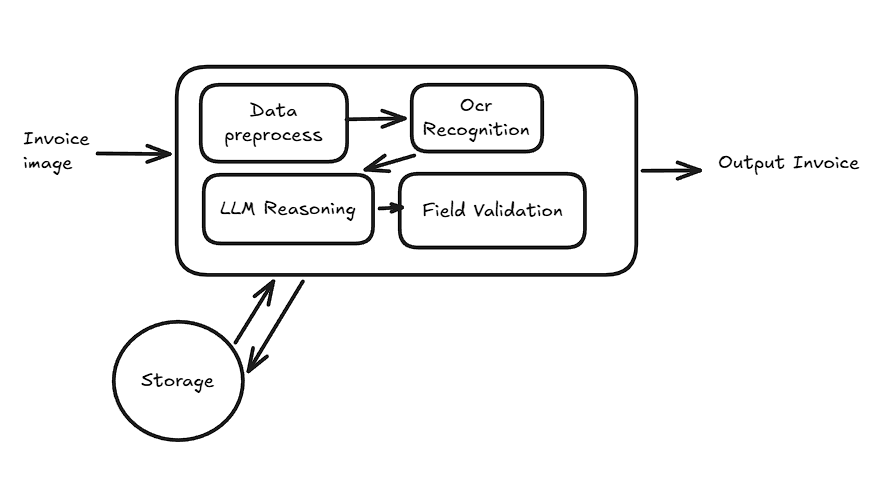

**Step-1 : batch Images read and process**

In [5]:
import os, glob, json, time, re
import numpy as np
import pandas as pd
import cv2
from PIL import Image
import pytesseract
from pytesseract import Output
from groq import Groq
from tqdm import tqdm

ROOT            = "/kaggle/input/datasets/osamahosamabdellatif/high-quality-invoice-images-for-ocr"
CHECKPOINT_FILE = "/kaggle/working/checkpoint.json"
OUTPUT_CSV      = "/kaggle/working/output.csv"

# client = Groq(api_key=secret_value_0)

REQUIRED_FIELDS = [
    "Seller Name", "Seller Tax ID", "Client Name", "Client Tax ID",
    "Invoice Number", "Invoice Date", "Net Worth", "VAT", "Gross Worth"
]

**Step 2:- Load Dataset and ground truth**

In [ ]:
batch1_df = pd.read_csv(r"/Users/grigoriostsakalis/.cache/kagglehub/datasets/osamahosamabdellatif/high-quality-invoice-images-for-ocr/versions/3/batch_1/batch_1/batch1_1.csv")

In [7]:
batch1_df.head()

,File Name,Json Data,OCRed Text
0,batch1-0494.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Clark...",Invoice no: 84652373 Date of issue: 02/23/2021...
1,batch1-0489.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Willi...",Invoice no: 37451664 Date of issue: 06/11/2020...
2,batch1-0499.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Heste...",Invoice no: 40108666 Date of issue: 02/07/2020...
3,batch1-0497.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Olson...",Invoice no: 73285932 Date of issue: 07/25/2017...
4,batch1-0081.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Wilso...",Invoice no: 15288019 Date of issue: 09/07/2014...


In [10]:
def discover_dataset(root):
    """
    Loads 50 images specified in the assignment.
    batch1-0331 to batch1-0381 inside batch_1/batch_1/batch1_1/
    """
    img_dir     = os.path.join(root, "batch_1", "batch_1", "batch1_1")
    csv_path    = os.path.join(root, "batch_1", "batch_1", "batch1_1.csv")

    dataset = []

    for i in range(331, 381):                          # 0331 to 0381 inclusive
        filename = f"batch1-{str(i).zfill(4)}.jpg"    # zero-padded e.g. batch1-0331.jpg
        img_path = os.path.join(img_dir, filename)

        if os.path.exists(img_path):
            dataset.append({
                "img_path" : img_path,
                "filename" : filename,
                "batch"    : "batch_1",
                "csv_path" : csv_path if os.path.exists(csv_path) else None,
            })
        else:
            print(f"Not found: {filename}")

    print(f"Loaded {len(dataset)} images (assignment scope: 50)")
    return dataset

ROOT = r"/Users/grigoriostsakalis/.cache/kagglehub/datasets/osamahosamabdellatif/high-quality-invoice-images-for-ocr/versions/3/"
dataset = discover_dataset(ROOT)

Loaded 50 images (assignment scope: 50)


In [12]:
for i in range(5):
    print(dataset[i])

{'img_path': '/Users/grigoriostsakalis/.cache/kagglehub/datasets/osamahosamabdellatif/high-quality-invoice-images-for-ocr/versions/3/batch_1/batch_1/batch1_1/batch1-0331.jpg', 'filename': 'batch1-0331.jpg', 'batch': 'batch_1', 'csv_path': '/Users/grigoriostsakalis/.cache/kagglehub/datasets/osamahosamabdellatif/high-quality-invoice-images-for-ocr/versions/3/batch_1/batch_1/batch1_1.csv'}
{'img_path': '/Users/grigoriostsakalis/.cache/kagglehub/datasets/osamahosamabdellatif/high-quality-invoice-images-for-ocr/versions/3/batch_1/batch_1/batch1_1/batch1-0332.jpg', 'filename': 'batch1-0332.jpg', 'batch': 'batch_1', 'csv_path': '/Users/grigoriostsakalis/.cache/kagglehub/datasets/osamahosamabdellatif/high-quality-invoice-images-for-ocr/versions/3/batch_1/batch_1/batch1_1.csv'}
{'img_path': '/Users/grigoriostsakalis/.cache/kagglehub/datasets/osamahosamabdellatif/high-quality-invoice-images-for-ocr/versions/3/batch_1/batch_1/batch1_1/batch1-0333.jpg', 'filename': 'batch1-0333.jpg', 'batch': 'bat

In [13]:
def load_ground_truth(csv_path):
    """
    Loads a ground truth CSV into a dict keyed by filename.
    Handles both 'filename' and 'image' column names.
    """
    if not csv_path or not os.path.exists(csv_path):
        return {}
        
    df = pd.read_csv(csv_path)
    print(f"GT columns found: {list(df.columns)}")
 
    gt_lookup = {}
    for _, row in df.iterrows():
        # Try common key column names
        key = str(
            row.get("filename") or
            row.get("image")    or
            row.get("file")     or
            row.iloc[0]
        )
        gt_lookup[key] = row.to_dict()
 
    return gt_lookup
 
 
# Preview one ground truth CSV so you can see its structure
sample_csv = next((d["csv_path"] for d in dataset if d["csv_path"]), None)
if sample_csv:
    print(f"\nPreviewing: {sample_csv}\n")
    display(pd.read_csv(sample_csv).head(3))


Previewing: /Users/grigoriostsakalis/.cache/kagglehub/datasets/osamahosamabdellatif/high-quality-invoice-images-for-ocr/versions/3/batch_1/batch_1/batch1_1.csv



,File Name,Json Data,OCRed Text
0,batch1-0494.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Clark...",Invoice no: 84652373 Date of issue: 02/23/2021...
1,batch1-0489.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Willi...",Invoice no: 37451664 Date of issue: 06/11/2020...
2,batch1-0499.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Heste...",Invoice no: 40108666 Date of issue: 02/07/2020...


**Step 3:- Image Preprocess and extraction**

In [14]:
def preprocess(img_path):
    """
    Grayscale + Otsu thresholding + slight dilation.
    Dramatically improves Tesseract accuracy on invoice scans.
    """
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not read image: {img_path}")
    _, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # Slight dilation to reconnect broken characters
    kernel = np.ones((1, 1), np.uint8)
    img    = cv2.dilate(img, kernel, iterations=1)
    return img
 
def extract_text(img):
    """
    Reconstructs invoice layout using word-level positional data.
    Handles two-column layouts by grouping words into rows by vertical
    proximity, then sorting each row left-to-right with column spacing.
    """
    dict_data = pytesseract.image_to_data(img, output_type=Output.DICT)
    df = pd.DataFrame(dict_data)
    df = df[(df["conf"] != -1) & (df["text"].str.strip() != "")].copy()
    df["conf"] = df["conf"].astype(int)

    if df.empty:
        return "", dict_data

    df = df.sort_values(by=["top", "left"]).reset_index(drop=True)
    rows = []
    current_row = [df.iloc[0]]

    for i in range(1, len(df)):
        word = df.iloc[i]
        last = current_row[-1]
        same_line = abs(word["top"] - last["top"]) <= 12

        if same_line:
            current_row.append(word)
        else:
            rows.append(current_row)
            current_row = [word]

    rows.append(current_row)
    all_lefts = df["left"].values
    page_width = int(df["left"].max() + df["width"].max())
    midpoint   = page_width // 2
    raw_text = ""

    for row_words in rows:
        row_words_sorted = sorted(row_words, key=lambda w: w["left"])
        line = ""
        prev_right = 0  
        for word in row_words_sorted:
            left  = word["left"]
            text  = word["text"]
            width = word["width"]

            # Calculate gap between previous word and this one
            gap = left - prev_right

            if prev_right == 0:
                line += text
            elif gap > midpoint * 0.4:
                line += "\t" + text
            elif gap > 15:
                line += " " + text
            else:
                line += " " + text

            prev_right = left + width

        raw_text += line.strip() + "\n"

    return raw_text.strip(), dict_data

**Test sample image**

/Users/grigoriostsakalis/.cache/kagglehub/datasets/osamahosamabdellatif/high-quality-invoice-images-for-ocr/versions/3/batch_1/batch_1/batch1_1/batch1-0341.jpg
Sample Invoice Image


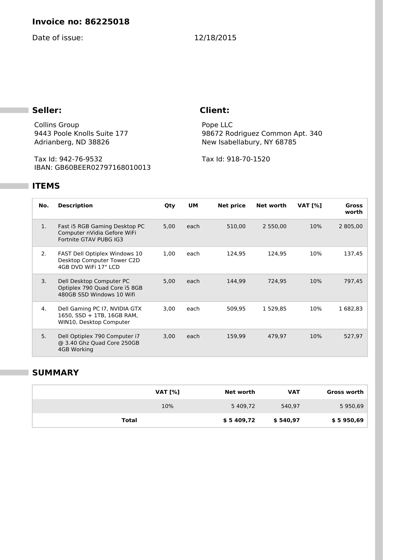


 Raw OCR Output
Invoice no: 86225018
Date of issue:	12/18/2015
Seller:	Client:
Collins Group	Pope LLC
9443 Poole Knolls Suite 177 98672 Rodriguez Common Apt. 340
Adrianberg, ND 38826	New Isabellabury, NY 68785
Tax Id: 942-76-9532	Tax Id: 918-70-1520
IBAN: GB60BEER02797168010013
ITEMS
No. Description Qty UM Net price Net worth VAT [%] Gross
worth
Fast i5 RGB Gaming Desktop PC 5,00 eac h 510,00 2 550,00 10% 2 805,00
Computer nVidia Gefore WiFi
Fortnite GTAV PUBG IG3
FAST Dell Optiplex Windows 10 1,00 eac 124,95 124,95 10% 137,45
Desktop Computer Tower C2D
4GB DVD WiFi 17" LCD
Dell Desktop Computer PC 5,00 eac 144,99 724,95 10% 797,45
Optiplex 790 Quad Core i5 8GB
480GB SSD Windows 10 Wifi
Dell Gaming PC 17, NVIDIA GTX 3,00 eac 509,95 1 529,85 10% 1 682,83
1650, SSD + 1TB, 16GB RAM,
WIN10, Desktop Computer
Dell Optiplex 790 Computer i7 3,00 eac 159,99 479,97 10% 527,97
@ 3.40 Ghz Quad Core 250GB
4GB Working
SUMMARY
VAT [%] Net worth VAT Gross worth
10% 5 409,72 540,97 5 950,69
Total $5 4

In [17]:
sample_img_path = dataset[10]["img_path"]
print(sample_img_path)
sample_img      = preprocess(sample_img_path)
sample_text , sample_dict    = extract_text(sample_img)
print("Sample Invoice Image")
display(Image.open(sample_img_path).resize((400, 560)))
print("\n Raw OCR Output")
print(sample_text)

**Step 4:- Extract Fields via LLM & reasoning**

In [22]:
def structure_for_llm(raw_text):
    """
    Converts tab-separated two-column OCR text into
    explicitly labelled SELLER/CLIENT blocks for the LLM.
    Removes spatial ambiguity entirely before the LLM sees it.
    """
    seller_lines = []
    client_lines = []
    general_lines = []
    
    for line in raw_text.split("\n"):
        if not line.strip():
            continue
        if "\t" in line and not "Date" in line:
            parts = [p.strip() for p in line.split("\t", 1)]
            left  = parts[0] if len(parts) > 0 else ""
            right = parts[1] if len(parts) > 1 else ""
            if left:  seller_lines.append(left)
            if right: client_lines.append(right)
        else:
            general_lines.append(line.strip())

    structured = ""

    if seller_lines:
        structured += "=== SELLER BLOCK ===\n"
        structured += "\n".join(seller_lines) + "\n\n"

    if client_lines:
        structured += "=== CLIENT BLOCK ===\n"
        structured += "\n".join(client_lines) + "\n\n"

    if general_lines:
        structured += "=== INVOICE DETAILS ===\n"
        structured += "\n".join(general_lines) + "\n"

    return structured

In [ ]:
def extract_fields_llm(raw_text:str):
    """
    Sends OCR text to Groq and gets structured fields back as JSON.
    Temperature=0 for deterministic extraction.
    """
    prompt = f"""
    You are an invoice field extractor. The input is raw OCR text — it may be jumbled, out of order, or have broken formatting. Do NOT read it top-to-bottom. Scan the ENTIRE text to find each field by its meaning.
    
    FIELDS TO EXTRACT:
    - Seller Name: Who issued/sold. A company or person name. Never an address, never the buyer.
    - Seller Tax ID: Tax or VAT ID of the seller. Usually near the seller's name or address block.
    - Client Name: Who is being billed. A company or person name. Never an address, never the seller.
    - Client Tax ID: Tax or VAT ID of the client. Usually near the client's name or address block.
    - Invoice Number: A reference code for this invoice. Often labeled "Invoice no", "Invoice #", "Ref".
    - Invoice Date: When the invoice was issued. Return as YYYY-MM-DD only.
    - Net Worth: Amount before tax. A number. Often labeled "Net worth", "Subtotal", "Net amount".
    - VAT: The tax amount in currency, not percentage. Often labeled "VAT", "Tax amount".
    - Gross Worth: Final total after tax. Often labeled "Gross worth", "Total", "Amount due".
    
    NUMBER EXTRACTION RULES (apply before returning any number):
    - OCR inserts spaces inside large numbers — always remove them first: "1 612,50" → 1612.50
    - Comma is often a decimal separator — convert to dot: "1.612,50" → 1612.50
    - Strip all currency symbols: $, €, £
    - Return as plain float, never a string
    
    SELF-CORRECTION:
    - Net Worth + VAT must equal Gross Worth (within 0.01 tolerance)
    - If they don't balance, one number is corrupted by OCR — derive it: 
      Net Worth = Gross Worth - VAT
      VAT = Gross Worth - Net Worth  
      Gross Worth = Net Worth + VAT
    - Use whichever two values you are most confident about to fix the third
    
    OUTPUT: Return raw JSON only. No markdown. No explanation. Use exact field names above. null for missing fields.
    
    OCR TEXT:
    {raw_text}
    """

    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "user", "content": prompt}],
        response_format={"type": "json_object"},
        temperature=0,
    )
    return json.loads(response.choices[0].message.content)

***LLM Fallback Logic***

In [ ]:
def regex_extraction_llm_fallback(structured_text):

    def get_block(label):
        m = re.search(rf'=== {label}.*?===\n(.*?)(?====|\Z)', structured_text, re.DOTALL)
        return m.group(1).strip() if m else ""

    def find(pattern, text):
        m = re.search(pattern, text, re.I | re.MULTILINE)
        return m.group(1).strip() if m else None

    def clean_num(val):
        if not val: return None
        val = re.sub(r'[$€£\s]', '', val).replace(',', '.')
        try:    return float(val)
        except: return None

    seller  = get_block("SELLER")
    client  = get_block("CLIENT")
    details = get_block("INVOICE DETAILS")

    return {
        "Seller Name"    : find(r'^([A-Za-z][\w\s\-\.]+)$', seller),
        "Seller Tax ID"  : find(r'Tax\s*Id[:\s]+([0-9\-]+)', seller),
        "Client Name"    : find(r'^([A-Za-z][\w\s\-\.]+)$', client),
        "Client Tax ID"  : find(r'Tax\s*Id[:\s]+([0-9\-]+)', client),
        "Invoice Number" : find(r'Invoice\s*no[:\s]+([A-Z0-9\-]+)', details),
        "Invoice Date"   : find(r'(\d{2}[\/\-]\d{2}[\/\-]\d{4})', details),
        "Net Worth"      : clean_num(find(r'Total\s+\$?\s*([\d\s,\.]+?)\s+\$', details)),
        "VAT"            : clean_num(find(r'Total\s+\$?[\d\s,\.]+\$\s*([\d\s,\.]+?)\s+\$', details)),
        "Gross Worth"    : clean_num(find(r'Total\s+.*\$\s*([\d\s,\.]+)$', details)),
    }

**Step 5:- Field validation**

In [ ]:
def validate_fields(fields):
    validation = {}

    for field in REQUIRED_FIELDS:
        val = fields.get(field)

        if val is None or str(val).strip() in ("", "null", "None"):
            validation[f"{field}_valid"] = False
            continue

        if field in ("Net Worth", "VAT", "Gross Worth"):
            try:
                float(str(val).replace(",", "").replace(" ", ""))
                validation[f"{field}_valid"] = True
            except ValueError:
                validation[f"{field}_valid"] = False

        elif field == "Invoice Date":
            validation[f"{field}_valid"] = bool(
                re.search(r"\d{2,4}[-/\.]\d{1,2}[-/\.]\d{1,4}", str(val))
            )

        else:
            validation[f"{field}_valid"] = True

    # ── Fix: only check field flags, not all_fields_found itself ──
    field_flags = [validation[f"{f}_valid"] for f in REQUIRED_FIELDS]
    validation["all_fields_found"] = all(field_flags)

    return validation

***Whole Image extraction & Data Validation Pipeline***

In [ ]:
def extract_fields(structured_text):
    """
    Stage 1: LLM extraction
    Stage 2: Regex fills any null fields LLM missed
    Stage 3: If LLM fails entirely, regex takes over
    """
    regex_fields = regex_extraction_llm_fallback(structured_text)

    try:
        llm_fields = extract_fields_llm(structured_text)

        # ── Fill null LLM fields from regex ───────────────────────
        for field in REQUIRED_FIELDS:
            if not llm_fields.get(field) and regex_fields.get(field):
                print(f"   '{field}' null from LLM → filled by regex: {regex_fields[field]}")
                llm_fields[field] = regex_fields[field]

        return llm_fields

    except Exception as e:
        print(f"⚠️  LLM failed entirely → using regex: {e}")
        return regex_fields
def run_pipeline(dataset, rate_limit_delay=0.8):
    results = []

    # ── Pre-load all ground truth CSVs ────────────────────────────
    gt_cache = {}
    for entry in dataset:
        cp = entry["csv_path"]
        if cp and cp not in gt_cache:
            gt_cache[cp] = load_ground_truth(cp)

    print(f"Total images to process: {len(dataset)}")

    for entry in tqdm(dataset, desc="Processing invoices"):
        img_path = entry["img_path"]
        filename = entry["filename"]

        try:
            # ── Stage 1: Preprocess + OCR ─────────────────────────
            img                 = preprocess(img_path)
            raw_text, dict_data = extract_text(img)

            # ── Stage 2: Structure ────────────────────────────────
            structured_text     = structure_for_llm(raw_text)

            # ── Stage 3: Extract (LLM + regex fallback combined) ──
            fields              = extract_fields(structured_text)

            # ── Stage 4: Validate (warnings only) ─────────────────
            validation          = validate_fields(fields)
            missing             = [f for f in REQUIRED_FIELDS if not validation[f"{f}_valid"]]
            if missing:
                print(f"\n⚠️  [{filename}] missing: {missing}")

            # ── Stage 5: Build row ────────────────────────────────
            row = {
                "filename" : filename,
                **{f: fields.get(f) for f in REQUIRED_FIELDS},
            }

        except Exception as e:
            print(f"\n❌ [{filename}]: {e}")
            row = {
                "filename" : filename,
                **{f: None for f in REQUIRED_FIELDS},
            }

        results.append(row)
        time.sleep(rate_limit_delay)

    return results


# ── Run ────────────────────────────────────────────────────────────
results = run_pipeline(dataset)

# ── Save output.csv ────────────────────────────────────────────────
df = pd.DataFrame(results)[["filename"] + REQUIRED_FIELDS]
df.to_csv("/kaggle/working/output.csv", index=False)

print(f"\n✅ Done: {len(df)} invoices → output.csv")
display(df.head(10))

# output.csv to requested json format
Example
[
  {
    "doc_id": "inv_001",
    "doc_type": "invoice",
    "vendor": "Adobe",
    "vendor_normalized": "adobe",
    "invoice_number": "ADB-2024-04-1182",
    "invoice_date": "2024-04-12",
    "due_date": "2024-05-12",
    "currency": "USD",
    "subtotal": 89.99,
    "tax": 0.00,
    "total": 89.99,
    "status": "paid",
    "line_items": [
      {"description": "Creative Cloud Teams April 2024", "qty": 1, "unit_price": 89.99, "line_total": 89.99}
    ],
    "raw_text": "Adobe Creative Cloud Teams April 2024 invoice..."
  },
  {
    "doc_id": "inv_002",
    "doc_type": "invoice",
    "vendor": "Adobe",
    "vendor_normalized": "adobe",
    "invoice_number": "ADB-2025-03-7714",
    "invoice_date": "2025-03-09",
    "due_date": "2025-04-09",
    "currency": "USD",
    "subtotal": 104.99,
    "tax": 0.00,
    "total": 104.99,
    "status": "paid",
    "line_items": [
      {"description": "Creative Cloud Teams March 2025", "qty": 1, "unit_price": 104.99, "line_total": 104.99}
    ],
    "raw_text": "Adobe Creative Cloud Teams March 2025 invoice..."
  },
  {
    "doc_id": "rcpt_003",
    "doc_type": "receipt",
    "vendor": "Athens Office Supplies",
    "vendor_normalized": "athens office supplies",
    "invoice_date": "2025-03-10",
    "currency": "EUR",
    "subtotal": 42.50,
    "tax": 10.20,
    "total": 52.70,
    "status": "captured",
    "line_items": [
      {"description": "Printer paper A4", "qty": 5, "unit_price": 5.00, "line_total": 25.00},
      {"description": "Black ink cartridge", "qty": 1, "unit_price": 17.50, "line_total": 17.50}
    ],
    "raw_text": "Retail receipt from Athens Office Supplies..."
  }
]

In [26]:
import json

# ── Read the output CSV ────────────────────────────────────────────
output_df = pd.read_csv(r"C:\Users\fkorniotis\code\makeathlon\makeathon-2026-WHOAMI-inform\.data\tesseract_validation\output.csv")

# ── Convert to desired JSON format ─────────────────────────────────
documents = []

for idx, row in output_df.iterrows():
    doc = {
        "doc_id": f"inv_{str(idx + 1).zfill(3)}",
        "doc_type": "invoice",
        "vendor": row["Seller Name"] if pd.notna(row["Seller Name"]) else None,
        "vendor_normalized": str(row["Seller Name"]).lower() if pd.notna(row["Seller Name"]) else None,
        "invoice_number": row["Invoice Number"] if pd.notna(row["Invoice Number"]) else None,
        "invoice_date": row["Invoice Date"] if pd.notna(row["Invoice Date"]) else None,
        "currency": "EUR",  # Default currency - adjust if needed
        "subtotal": float(row["Net Worth"]) if pd.notna(row["Net Worth"]) else None,
        "tax": float(row["VAT"]) if pd.notna(row["VAT"]) else None,
        "total": float(row["Gross Worth"]) if pd.notna(row["Gross Worth"]) else None,
        "status": "captured",  # Default status
        "line_items": [],  # Would need more granular data to populate
        "raw_text": "",  # Would need to store raw OCR text from pipeline
        "client_name": row["Client Name"] if pd.notna(row["Client Name"]) else None,
        "client_tax_id": row["Client Tax ID"] if pd.notna(row["Client Tax ID"]) else None,
        "seller_tax_id": row["Seller Tax ID"] if pd.notna(row["Seller Tax ID"]) else None,
    }
    documents.append(doc)

# ── Save as JSON ───────────────────────────────────────────────────
output_json_path = r"C:\Users\fkorniotis\code\makeathlon\makeathon-2026-WHOAMI-inform\.data\tesseract_validation/invoices.json"
with open(output_json_path, "w", encoding="utf-8") as f:
    json.dump(documents, f, indent=2, ensure_ascii=False)

print(f"✅ Converted {len(documents)} invoices → {output_json_path}")

# ── Preview first 2 documents ──────────────────────────────────────
print("\nPreview of first invoice:")
display(documents[0] if documents else "No documents")

✅ Converted 51 invoices → C:\Users\fkorniotis\code\makeathlon\makeathon-2026-WHOAMI-inform\.data\tesseract_validation/invoices.json

Preview of first invoice:


{'doc_id': 'inv_001',
 'doc_type': 'invoice',
 'vendor': 'Ochoa-Scott',
 'vendor_normalized': 'ochoa-scott',
 'invoice_number': 94138597,
 'invoice_date': '2018-02-05',
 'currency': 'EUR',
 'subtotal': 1612.5,
 'tax': 161.25,
 'total': 1773.75,
 'status': 'captured',
 'line_items': [],
 'raw_text': '',
 'client_name': 'Green LLC',
 'client_tax_id': '965-99-1263',
 'seller_tax_id': '921-82-1053'}